# Brain Tumor Segmentation using nnU-Net V2

### This notebook is designed to train nnU-Net V2 (no-new-Net) step by step for automatic brain tumor segmentation on the BraTS2020 dataset.

nnU-Net is a self-configuring deep learning framework for medical image segmentation. It automatically adapts to any new dataset and determines the preprocessing, network architecture, training, and post-processing pipeline.

## Dataset: BraTS2020
- **Modalities**: 4 MRI sequences (FLAIR, T1, T1CE, T2)
- **Classes**: Background, Edema, Non-enhancing tumor, Enhancing tumor

## 1. Environment Setup

In [3]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
INFO: pip is looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 76.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 51.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 106.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 2.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 3.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 2.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 33.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 14.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 9.3 MB/s eta 0:00:000

In [4]:
!cp -r "/kaggle/input/nnunet-new/nnUNet" "/kaggle/working/"

In [5]:
%cd /kaggle/working/nnUNet
!pip install -e .

/kaggle/working/nnUNet
Obtaining file:///kaggle/working/nnUNet
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 79.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 115.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 8.0 MB/s eta 0:00:00
  Building editable for nnunetv2 (pyproject.toml) ... done
 

In [6]:
!pip install thop monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 33.4 MB/s eta 0:00:0000:0100:01


In [7]:
!pip install --upgrade git+https://github.com/FabianIsensee/hiddenlayer.git

  Cloning https://github.com/FabianIsensee/hiddenlayer.git to /tmp/pip-req-build-u5zd48e3
  Running command git clone --filter=blob:none --quiet https://github.com/FabianIsensee/hiddenlayer.git /tmp/pip-req-build-u5zd48e3
  Resolved https://github.com/FabianIsensee/hiddenlayer.git to commit b7263b6dc4569da1b6dea5964e1eac78fa32fa77
  Preparing metadata (setup.py) ... done
  Created wheel for hiddenlayer: filename=hiddenlayer-0.2-py3-none-any.whl size=20004 sha256=98ac9a732b7359ec994641c646edafd0c402b9fc388fa7597f56fb1a7d3dd92c
  Stored in directory: /tmp/pip-ephem-wheel-cache-57r8vx8h/wheels/5e/bb/33/76bf11a993485ba52708dbbb7f9612cbb8bb640d4580967ab1
Successfully built hiddenlayer


In [8]:
!pip install protobuf==3.20.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 4.3 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
onnx 1.18.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 3.20.3 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
tens

In [9]:
# Disable torch.compile to avoid Triton/Inductor errors on older GPUs
os.environ["nnUNet_compile"] = "f"

## 2. Setting Up nnU-Net Directory Structure

In [ ]:
import os
import shutil
from pathlib import Path
import subprocess

In [11]:
input_root = Path("/kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData")

input_cases = [d for d in input_root.iterdir() if d.is_dir()]

print("Total subjects:", len(input_cases))

Total subjects: 369


In [12]:
# Dataset identifiers
dataset_id = "001"
dataset_name = "BraTS2020"

# Destination: nnU-Net raw structure
dataset_root = Path(f"/kaggle/working/nnUNet_raw_data_base/nnUNet_raw/Dataset{dataset_id}_{dataset_name}")
imagesTr = dataset_root / "imagesTr"
labelsTr = dataset_root / "labelsTr"
imagesTr.mkdir(parents=True, exist_ok=True)
labelsTr.mkdir(parents=True, exist_ok=True)

## 3. Data Preparation

### Creating Symbolic Links
Instead of copying large files, symbolic link are created to avoid disk space issues

### BraTS Modalities Mapping
- **0000** → FLAIR (Fluid Attenuated Inversion Recovery)
- **0001** → T1 (T1-weighted)
- **0002** → T1CE (T1-weighted with contrast enhancement)
- **0003** → T2 (T2-weighted)

In [ ]:
# Modality suffix mapping
modality_suffixes = {
    "flair": "0000",
    "t1": "0001",
    "t1ce": "0002",
    "t2": "0003"
}

total_cases_needed = 200
all_case_dirs = sorted([d for d in input_root.iterdir() if d.is_dir()]) [:total_cases_needed]

print(f"Selected {len(all_case_dirs)} subjects for processing.")

# Loop through selected cases
for case_dir in all_case_dirs:
    case_id = case_dir.name  # e.g., BraTS20_Training_001

    # Create symbolic links for each modality
    for modality, channel in modality_suffixes.items():
        src = case_dir / f"{case_id}_{modality}.nii"
        if src.exists():
            dst = imagesTr / f"{case_id}_{channel}.nii"
            subprocess.run(["ln", "-s", str(src), str(dst)], check=False)

    # Create symbolic link for segmentation mask
    seg = case_dir / f"{case_id}_seg.nii"
    if seg.exists():
        dst_seg = labelsTr / f"{case_id}.nii"
        subprocess.run(["ln", "-s", str(seg), str(dst_seg)], check=False)

print(f"Symlinks created for {len(all_case_dirs)} BraTS2020 subjects")

Selected 200 subjects for processing.
Symlinks created for 200 BraTS2020 subjects


## 4. Creating dataset.json Configuration

This file tells nnU-Net about:
- Number of input channels (modalities)
- Label classes and their meanings
- Number of training cases
- File format


In [15]:
import json

dataset_json = {
    "channel_names": {
        "0": "FLAIR",
        "1": "T1",
        "2": "T1CE",
        "3": "T2"
    },
    "labels": {
        "background": 0,
        "edema": 1,
        "non_enhancing_tumor": 2,
        "enhancing_tumor": 3
    },
    "regions_class_order": [1, 2, 3],
    "numTraining": len(list(labelsTr.glob("*.nii"))),
    "file_ending": ".nii",
    "overwrite_image_reader_writer": "SimpleITKIO"
}

with open(dataset_root / "dataset.json", "w") as f:
    json.dump(dataset_json, f, indent=4)

print("dataset.json created at:", dataset_root)


dataset.json created at: /kaggle/working/nnUNet_raw_data_base/nnUNet_raw/Dataset001_BraTS2020


In [16]:
print("Sample image files:")
for i, f in enumerate(sorted(imagesTr.glob("*.nii"))[:8]):
    print(f"-", f.name)
print("\nSample label files:")
for i, f in enumerate(sorted(labelsTr.glob("*.nii"))[:8]):
    print(f"-", f.name)

print(f"\nTotal training subjects: {len(list(labelsTr.glob('*.nii')))}")

Sample image files:
- BraTS20_Training_001_0000.nii
- BraTS20_Training_001_0001.nii
- BraTS20_Training_001_0002.nii
- BraTS20_Training_001_0003.nii
- BraTS20_Training_002_0000.nii
- BraTS20_Training_002_0001.nii
- BraTS20_Training_002_0002.nii
- BraTS20_Training_002_0003.nii

Sample label files:
- BraTS20_Training_001.nii
- BraTS20_Training_002.nii
- BraTS20_Training_003.nii
- BraTS20_Training_004.nii
- BraTS20_Training_005.nii
- BraTS20_Training_006.nii
- BraTS20_Training_007.nii
- BraTS20_Training_008.nii

Total training subjects: 200


### Setup environment variables

In [17]:
os.environ["nnUNet_raw"] = "/kaggle/working/nnUNet_raw_data_base/nnUNet_raw"
os.environ["nnUNet_preprocessed"] = "/kaggle/working/nnUNet_preprocessed"
os.environ["nnUNet_results"] = "/kaggle/working/nnUNet_results"

print("nnU-Net paths set:")
for k in ["nnUNet_raw", "nnUNet_preprocessed", "nnUNet_results"]:
    print(f"{k} = {os.environ[k]}")

nnU-Net paths set:
nnUNet_raw = /kaggle/working/nnUNet_raw_data_base/nnUNet_raw
nnUNet_preprocessed = /kaggle/working/nnUNet_preprocessed
nnUNet_results = /kaggle/working/nnUNet_results


In [18]:
dataset_root = Path("/kaggle/working/nnUNet_raw_data_base/nnUNet_raw/Dataset001_BraTS2020")
labelsTr = dataset_root / "labelsTr"

num_cases = len(list(labelsTr.glob("*.nii")))
print(f"Total label files found: {num_cases}")

Total label files found: 200


### Check for any images without labels

In [19]:
from collections import defaultdict

imagesTr_dir = "/kaggle/working/nnUNet_raw_data_base/nnUNet_raw/Dataset001_BraTS2020/imagesTr"
labelsTr_dir = "/kaggle/working/nnUNet_raw_data_base/nnUNet_raw/Dataset001_BraTS2020/labelsTr"
missing_dir = "/kaggle/working/missing_label_cases"
os.makedirs(missing_dir, exist_ok=True)

# Step 1: Collect IDs from labels
label_ids = {os.path.basename(f).replace('.nii', '') for f in os.listdir(labelsTr_dir) if f.endswith('.nii')}

# Step 2: Group image files by case ID
image_dict = defaultdict(list)
for f in os.listdir(imagesTr_dir):
    if not f.endswith(".nii"):
        continue
    base_id = "_".join(f.split('_')[:3])
    image_dict[base_id].append(f)

# Step 3: Identify cases with images but no label
extra_image_cases = [cid for cid, imgs in image_dict.items() if cid not in label_ids]

print("Extra image cases without labels:")
for c in extra_image_cases:
    print(c)
print(f"\nTotal: {len(extra_image_cases)} case(s) missing labels.\n")

# Step 4: Move extra image cases to 'missing_label_cases'
for case in extra_image_cases:
    for f in image_dict[case]:
        src = os.path.join(imagesTr_dir, f)
        if os.path.exists(src):
            shutil.move(src, os.path.join(missing_dir, f))
            print(f"Moved {f}")
        else:
            print(f"File not found (already moved or different extension): {f}")

Extra image cases without labels:

Total: 0 case(s) missing labels.



## 5. Remapping BraTS Labels

BraTS uses labels **{0, 1, 2, 4}** but nnU-Net needs **consecutive** labels **{0, 1, 2, 3}**.

### Label Mapping
| Original | Tissue Type | New Label |
|----------|-------------|----------|
| 0 | Background | 0 |
| 1 | Edema | 1 |
| 2 | Non-enhancing | 2 |
| 4 | Enhancing | 3 |


In [20]:
import nibabel as nib
import numpy as np

labels_dir = "/kaggle/working/nnUNet_raw_data_base/nnUNet_raw/Dataset001_BraTS2020/labelsTr"
fixed_dir = "/kaggle/working/nnUNet_fixed_labels"
os.makedirs(fixed_dir, exist_ok=True)

for file in os.listdir(labels_dir):
    if not file.endswith(".nii"):
        continue
    path = os.path.join(labels_dir, file)
    img = nib.load(path)
    data = img.get_fdata()

    # Check and remap class 4 → 3
    if 4 in np.unique(data):
        print(f"Fixing {file} (relabeling 4 → 3)")
        data[data == 4] = 3
    else:
        print(f"No label 4 found in {file}")

    # Save to fixed_dir
    fixed_path = os.path.join(fixed_dir, file)
    fixed_img = nib.Nifti1Image(data.astype(np.uint8), img.affine, img.header)
    nib.save(fixed_img, fixed_path)

print("All label files processed and saved to:", fixed_dir)

Fixing BraTS20_Training_157.nii (relabeling 4 → 3)
Fixing BraTS20_Training_185.nii (relabeling 4 → 3)
Fixing BraTS20_Training_174.nii (relabeling 4 → 3)
Fixing BraTS20_Training_150.nii (relabeling 4 → 3)
Fixing BraTS20_Training_121.nii (relabeling 4 → 3)
Fixing BraTS20_Training_016.nii (relabeling 4 → 3)
Fixing BraTS20_Training_094.nii (relabeling 4 → 3)
Fixing BraTS20_Training_040.nii (relabeling 4 → 3)
Fixing BraTS20_Training_095.nii (relabeling 4 → 3)
Fixing BraTS20_Training_028.nii (relabeling 4 → 3)
Fixing BraTS20_Training_019.nii (relabeling 4 → 3)
Fixing BraTS20_Training_123.nii (relabeling 4 → 3)
Fixing BraTS20_Training_024.nii (relabeling 4 → 3)
Fixing BraTS20_Training_177.nii (relabeling 4 → 3)
Fixing BraTS20_Training_200.nii (relabeling 4 → 3)
Fixing BraTS20_Training_115.nii (relabeling 4 → 3)
Fixing BraTS20_Training_108.nii (relabeling 4 → 3)
Fixing BraTS20_Training_166.nii (relabeling 4 → 3)
Fixing BraTS20_Training_064.nii (relabeling 4 → 3)
Fixing BraTS20_Training_031.nii

In [21]:
labelsTr_dir = "/kaggle/working/nnUNet_raw_data_base/nnUNet_raw/Dataset001_BraTS2020/labelsTr"
fixed_dir = "/kaggle/working/nnUNet_fixed_labels"

for f in os.listdir(fixed_dir):
    src = os.path.join(fixed_dir, f)
    dst = os.path.join(labelsTr_dir, f)

    # Remove symlink if it exists
    if os.path.islink(dst):
        os.unlink(dst)

    # Copy actual file
    shutil.copy2(src, dst)

print("All fixed label files replaced successfully!")

All fixed label files replaced successfully!


## 6. Data Verification and Preprocessing

nnU-Net automatically:
- Analyzes dataset properties (spacing, intensity distributions)
- Determines optimal patch size
- Chooses network architecture (2D, 3D full-res, 3D low-res, or cascade)
- Creates training/validation splits
- Preprocesses and saves data


In [22]:
!nnUNetv2_plan_and_preprocess -d 1 --verify_dataset_integrity

Fingerprint extraction...
Dataset001_BraTS2020
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> reader/writer
100%|█████████████████████████████████████████| 200/200 [01:19<00:00,  2.51it/s]
Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Dropping 3d_lowres config because the image size difference to 3d_fullres is too small. 3d_fullres: [139.5 170.  138. ], 3d_lowres: [140, 170, 138]
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor

## 7. Training the Model

From the dataset, 200 subjects were chosen.  80 % of data was allocated for training and 20 % for validation.

The model was trained 100 epochs on t4 GPU from Kaggle with 15 GB VRAM.

### Parameters
- **DATASET_ID**: `1` (Dataset001_BraTS2020)
- **CONFIGURATION**: `3d_fullres` (3D U-Net at full resolution)
- **FOLD**: `0` (first cross-validation fold)

### 5-Fold Cross-Validation
nnU-Net splits data into 5 folds by default. Here 0 fold is used


In [ ]:
# Define the path to the trainer file
trainer_path = "/kaggle/working/nnUNet/nnunetv2/training/nnUNetTrainer/nnUNetTrainer.py"

# Read the file
with open(trainer_path, "r") as f:
    code = f.read()

# Replace the default epoch count
default_setting = "self.num_epochs = 1000"
new_setting = "self.num_epochs = 100"

if default_setting in code:
    new_code = code.replace(default_setting, new_setting)

    # Write the changes back to the file
    with open(trainer_path, "w") as f:
        f.write(new_code)
    print(f"Changed epoch in {trainer_path}")
else:
    print("Could not find 'self.num_epochs = 1000'.")

Changed epoch in /kaggle/working/nnUNet/nnunetv2/training/nnUNetTrainer/nnUNetTrainer.py


In [23]:
from nnunetv2.paths import nnUNet_preprocessed

# RAW DATA to get the list of files
raw_labels_path = Path("/kaggle/working/nnUNet_raw_data_base/nnUNet_raw/Dataset001_BraTS2020/labelsTr")

# Path where the split file must be saved (Base preprocessed folder)
preprocessed_folder = Path(nnUNet_preprocessed) / "Dataset001_BraTS2020"

# Get identifiers from .nii files in Raw Data (Guaranteed to exist)
# We strip the .nii extension to get the Case ID
case_identifiers = [f.replace('.nii', '') for f in os.listdir(raw_labels_path) if f.endswith('.nii')]
case_identifiers = sorted(case_identifiers)


# Split (80% Train, 20% Val)
split_index = int(len(case_identifiers) * 0.8)
train_keys = case_identifiers[:split_index]
val_keys = case_identifiers[split_index:]

print(f"Training on {len(train_keys)} samples")
print(f"Validating on {len(val_keys)} samples")

# Create the split dictionary in nnU-Net format
splits = []
splits.append({
    "train": train_keys,
    "val": val_keys
})

# Save to splits_final.json
with open(preprocessed_folder / "splits_final.json", "w") as f:
    json.dump(splits, f)

print(f"Custom split saved to {preprocessed_folder / 'splits_final.json'}")

Training on 160 samples
Validating on 40 samples
Custom split saved to /kaggle/working/nnUNet_preprocessed/Dataset001_BraTS2020/splits_final.json


In [24]:
!nnUNetv2_train 1 3d_fullres 0


############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2025-12-11 09:27:55.797627: do_dummy_2d_data_aug: False
2025-12-11 09:27:55.798446: Using splits from existing split file: /kaggle/working/nnUNet_preprocessed/Dataset001_BraTS2020/splits_final.json
2025-12-11 09:27:55.798619: The split file contains 1 splits.
2025-12-11 09:27:55.798676: Desired 

Found log file: training_log_2025_12_11_09_27_54.txt


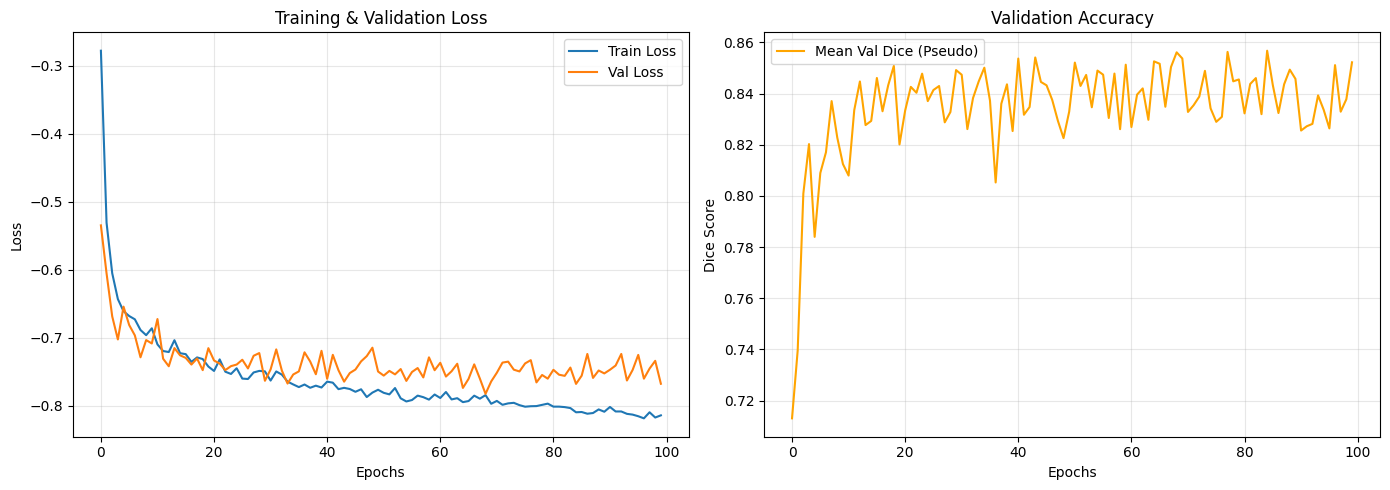

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

# folder containing the logs
log_folder = Path("/kaggle/working/nnUNet_results/Dataset001_BraTS2020/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_0")


# We look for any file matching "training_log_*.txt"
log_files = list(log_folder.glob("training_log_*.txt"))

if not log_files:
    print("Error: No training log found.")
else:
    # Sort by modification time to get the most recent one
    latest_log = max(log_files, key=os.path.getmtime)
    print(f"Found log file: {latest_log.name}")

    # 3. PARSE THE TEXT FILE
    # nnU-Net logs are text, so we read line by line and extract numbers
    train_losses = []
    val_losses = []
    val_accuracies = []

    with open(latest_log, 'r') as f:
        for line in f:
            # Extract Train Loss
            if "train_loss" in line:
                try:
                    val = float(line.split("train_loss")[-1].strip())
                    train_losses.append(val)
                except: pass

            # Extract Validation Loss
            elif "val_loss" in line:
                try:
                    val = float(line.split("val_loss")[-1].strip())
                    val_losses.append(val)
                except: pass

            # Extract Pseudo Dice
            elif "Pseudo dice" in line:
                try:
                    list_str = line.split("Pseudo dice")[-1].strip()
                    list_str = list_str.replace('[', '').replace(']', '')
                    dice_values = [float(x) for x in list_str.split(',')]
                    val_accuracies.append(np.mean(dice_values))
                except: pass

    # 4. PLOTTING
    if len(train_losses) == 0:
        print("Log file exists but contains no data.")
    else:
        epochs = range(len(train_losses))

        plt.figure(figsize=(14, 5))

        # Loss Plot
        plt.subplot(1, 2, 1)
        plt.plot(epochs, train_losses, label='Train Loss')
        # Handle case where val_loss might be missing for some epochs
        if len(val_losses) == len(epochs):
            plt.plot(epochs, val_losses, label='Val Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.title('Training & Validation Loss')
        plt.grid(True, alpha=0.3)

        # Accuracy Plot
        plt.subplot(1, 2, 2)
        if len(val_accuracies) > 0:
            plt.plot(range(len(val_accuracies)), val_accuracies, label='Mean Val Dice (Pseudo)', color='orange')
            plt.xlabel('Epochs')
            plt.ylabel('Dice Score')
            plt.legend()
            plt.title('Validation Accuracy')
            plt.grid(True, alpha=0.3)
        else:
            plt.text(0.5, 0.5, 'No Accuracy Data', ha='center')

        plt.tight_layout()
        plt.show()

## 8. Evaluation


In [ ]:
import time
import torch
from thop import profile
from monai.metrics import DiceMetric, compute_iou, compute_surface_dice
from nnunetv2.inference.predict_from_raw_data import nnUNetPredictor

dataset_name = "Dataset001_BraTS2020"
nnUNet_raw = Path("/kaggle/working/nnUNet_raw_data_base/nnUNet_raw")
imagesTr = nnUNet_raw / dataset_name / "imagesTr"
labelsTr = nnUNet_raw / dataset_name / "labelsTr"
output_folder = Path("/kaggle/working/predictions")
model_folder = "/kaggle/working/nnUNet_results/Dataset001_BraTS2020/nnUNetTrainer__nnUNetPlans__3d_fullres"
split_file = "/kaggle/working/nnUNet_preprocessed/Dataset001_BraTS2020/splits_final.json"

os.makedirs(output_folder, exist_ok=True)

# load validation keys
if 'val_keys' not in locals():
    with open(split_file, 'r') as f:
        val_keys = json.load(f)[0]['val']

# GFLOPS Calculation
print("--- Model Complexity ---")

# Init temp predictor for profiling
temp_predictor = nnUNetPredictor(
    tile_step_size=0.5,
    use_mirroring=True,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    verbose=False
)
temp_predictor.initialize_from_trained_model_folder(
    model_training_output_dir=model_folder,
    use_folds=(0,),
    checkpoint_name="checkpoint_final.pth"
)

model = temp_predictor.network
model.eval()

# avoids tensor mismatch errors (112 causes alignment issues)
patch_size = (128, 128, 128)
dummy_input = torch.randn(1, 4, *patch_size).to(next(model.parameters()).device)
flops, params = profile(model, inputs=(dummy_input, ), verbose=False)
gflops = flops / 1e9

del temp_predictor, model, dummy_input
torch.cuda.empty_cache()
print(f"Model GFLOPs calculated: {gflops:.2f}")


# inference
print("\n--- Validation testing ---")

# Re-initialize predictor for inference
predictor = nnUNetPredictor(
    tile_step_size=0.5,
    use_mirroring=True,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    verbose=False
)
predictor.initialize_from_trained_model_folder(
    model_training_output_dir=model_folder,
    use_folds=(0,),
    checkpoint_name="checkpoint_final.pth"
)

# Prepare file lists
val_input_files = []
val_output_files = []

for case_id in val_keys:
    case_files = [
        str(imagesTr / f"{case_id}_0000.nii"),
        str(imagesTr / f"{case_id}_0001.nii"),
        str(imagesTr / f"{case_id}_0002.nii"),
        str(imagesTr / f"{case_id}_0003.nii")
    ]
    val_input_files.append(case_files)
    val_output_files.append(str(output_folder / case_id))

print(f"Processing {len(val_keys)} validation cases...")
start_time = time.time()

predictor.predict_from_files(
    list_of_lists_or_source_folder=val_input_files,
    output_folder_or_list_of_truncated_output_files=val_output_files,
    save_probabilities=False,
    overwrite=True
)

end_time = time.time()
total_time = end_time - start_time
avg_time_per_sample = total_time / len(val_keys)


# Evaluation
print("\n--- Evaluation Results (BraTS Regions) ---")
dice_metric = DiceMetric(include_background=False, reduction="mean")

# Store mean scores per case
dice_scores = []
jaccard_scores = []
nsd_scores = []
nsd_tolerance = [1.0]

for case_id in val_keys:
    gt_path = labelsTr / f"{case_id}.nii"
    pred_path = output_folder / f"{case_id}.nii"

    gt_nii = nib.load(gt_path)
    pred_nii = nib.load(pred_path)

    gt_data = gt_nii.get_fdata()
    pred_data = pred_nii.get_fdata()
    img_spacing = [float(x) for x in gt_nii.header.get_zooms()[:3]]

    gt_wt = (gt_data > 0)
    pred_wt = (pred_data > 0)

    gt_tc = (gt_data == 2) | (gt_data == 3)
    pred_tc = (pred_data == 2) | (pred_data == 3)

    gt_et = (gt_data == 3)
    pred_et = (pred_data == 3)

    regions = [(gt_wt, pred_wt), (gt_tc, pred_tc), (gt_et, pred_et)]

    case_dices = []
    case_ious = []
    case_nsds = []

    for (gt_mask, pred_mask) in regions:
        gt_tensor = torch.tensor(gt_mask).float().unsqueeze(0).unsqueeze(0)
        pred_tensor = torch.tensor(pred_mask).float().unsqueeze(0).unsqueeze(0)

        # Dice
        d = dice_metric(y_pred=pred_tensor, y=gt_tensor).item()
        case_dices.append(d)

        # Jaccard
        i = compute_iou(y_pred=pred_tensor, y=gt_tensor).item()
        case_ious.append(i)

        # NSD
        n = compute_surface_dice(
            y_pred=pred_tensor,
            y=gt_tensor,
            class_thresholds=nsd_tolerance,
            spacing=img_spacing
        ).item()

        if np.isnan(n): n = 0.0
        case_nsds.append(n)

    # average the 3 regions to get case score
    dice_scores.append(np.mean(case_dices))
    jaccard_scores.append(np.mean(case_ious))
    nsd_scores.append(np.mean(case_nsds))

# print results
print("=" * 40)
print(f"Inference Performance (Average over {len(val_keys)} samples):")
print(f"  - Avg Time per Subject : {avg_time_per_sample:.4f} seconds")
print(f"  - Model Complexity     : {gflops:.2f} GFLOPs")
print("-" * 40)
print(f"Segmentation Quality (Mean of WT, TC, ET):")
print(f"  - Mean Dice Score      : {np.mean(dice_scores):.4f}")
print(f"  - Mean Jaccard Index   : {np.mean(jaccard_scores):.4f}")
print(f"  - Mean NSD (1mm)       : {np.mean(nsd_scores):.4f}")
print("=" * 40)

--- Model Complexity ---
Model GFLOPs calculated: 3707.11

--- Validation testing ---
Processing 40 validation cases...
There are 40 cases in the source folder
I am processing 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 40 cases that I would like to predict

Predicting BraTS20_Training_161:
perform_everything_on_device: True


100%|██████████| 8/8 [00:07<00:00,  1.12it/s]


sending off prediction to background worker for resampling and export
done with BraTS20_Training_161

Predicting BraTS20_Training_162:
perform_everything_on_device: True


100%|██████████| 8/8 [00:07<00:00,  1.09it/s]


sending off prediction to background worker for resampling and export
done with BraTS20_Training_162

Predicting BraTS20_Training_163:
perform_everything_on_device: True


...

sending off prediction to background worker for resampling and export
done with BraTS20_Training_199

Predicting BraTS20_Training_200:
perform_everything_on_device: True


100%|██████████| 8/8 [00:07<00:00,  1.04it/s]


sending off prediction to background worker for resampling and export
done with BraTS20_Training_200

--- Evaluation Results (BraTS Regions) ---


/usr/local/lib/python3.11/dist-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)


Inference Performance (Average over 40 samples):
  - Avg Time per Subject : 8.7196 seconds
  - Model Complexity     : 3707.11 GFLOPs
----------------------------------------
Segmentation Quality (Mean of WT, TC, ET):
  - Mean Dice Score      : 0.8876
  - Mean Jaccard Index   : 0.8057
  - Mean NSD (1mm)       : 0.8026


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


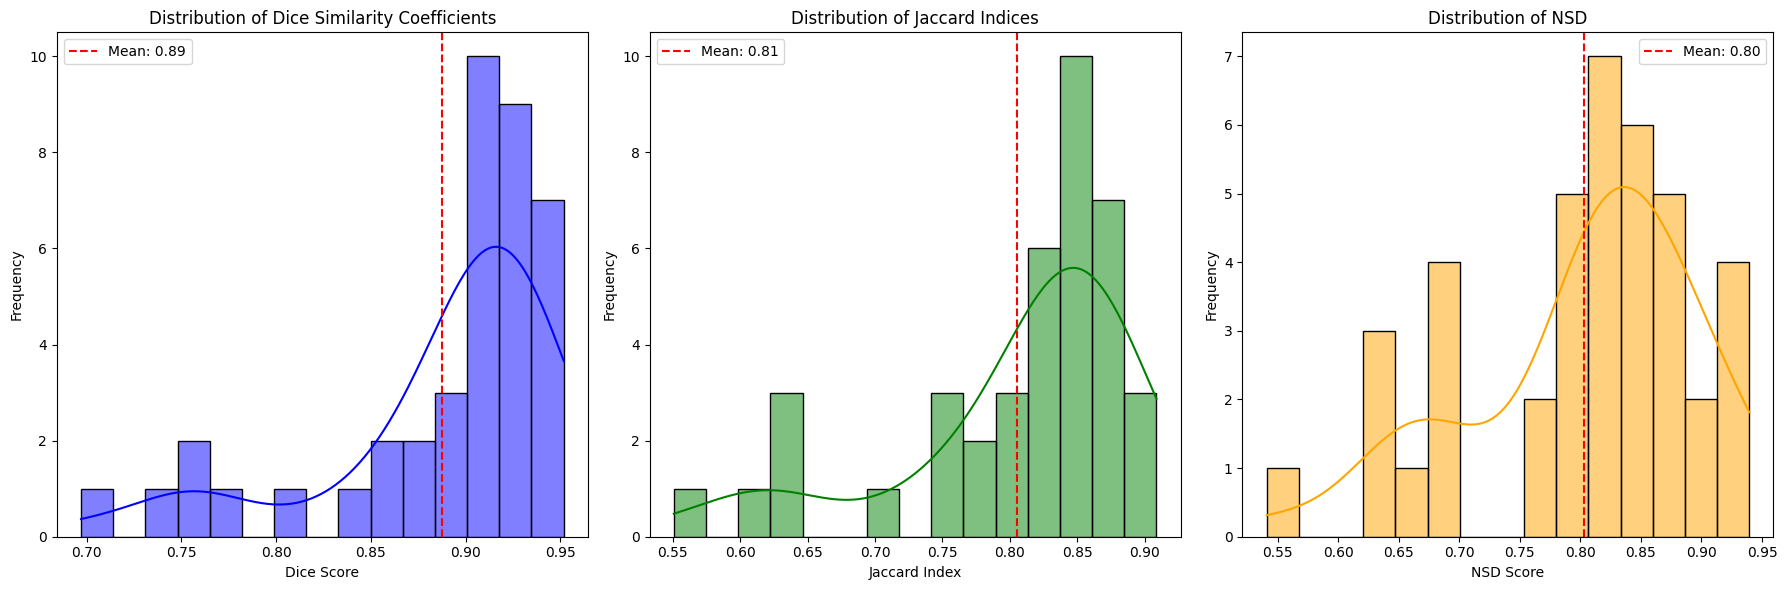

In [ ]:
%matplotlib inline
import seaborn as sns

plt.figure(figsize=(18, 6))

# plot Dice Histogram
plt.subplot(1, 3, 1)
sns.histplot(dice_scores, kde=True, color='blue', bins=15)
plt.title('Distribution of Dice Similarity Coefficients')
plt.xlabel('Dice Score')
plt.ylabel('Frequency')
plt.axvline(np.mean(dice_scores), color='red', linestyle='--', label=f'Mean: {np.mean(dice_scores):.2f}')
plt.legend()

# plot Jaccard histogram
plt.subplot(1, 3, 2)
sns.histplot(jaccard_scores, kde=True, color='green', bins=15)
plt.title('Distribution of Jaccard Indices')
plt.xlabel('Jaccard Index')
plt.ylabel('Frequency')
plt.axvline(np.mean(jaccard_scores), color='red', linestyle='--', label=f'Mean: {np.mean(jaccard_scores):.2f}')
plt.legend()

# plot NSD histogram
plt.subplot(1, 3, 3)
sns.histplot(nsd_scores, kde=True, color='orange', bins=15)
plt.title('Distribution of NSD')
plt.xlabel('NSD Score')
plt.ylabel('Frequency')
plt.axvline(np.mean(nsd_scores), color='red', linestyle='--', label=f'Mean: {np.mean(nsd_scores):.2f}')
plt.legend()

plt.tight_layout()
plt.show()

---
## 9. Visualizing Results

### What We'll Visualize
- Original MRI scan (grayscale)
- Predicted tumor segmentation (colored overlay)


Visualizing cases: ['BraTS20_Training_161', 'BraTS20_Training_162', 'BraTS20_Training_163']


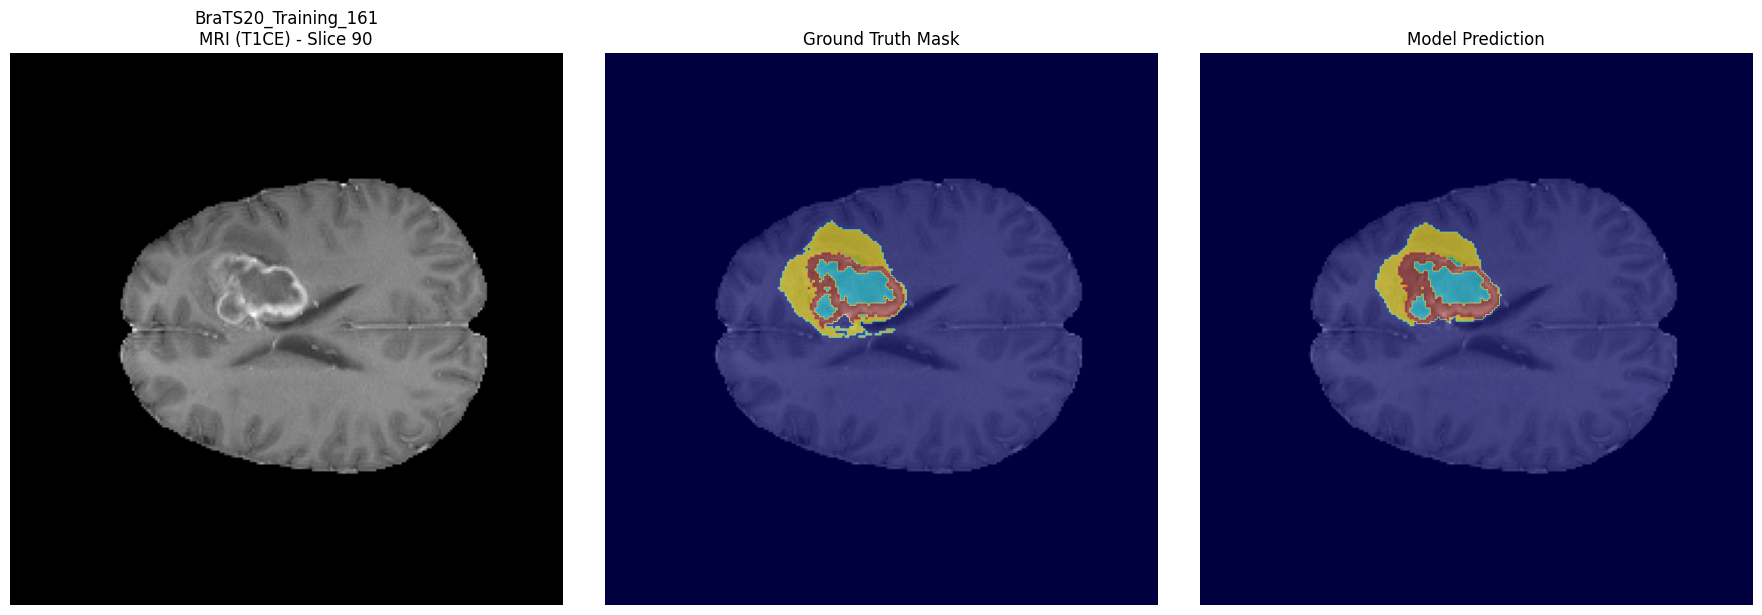

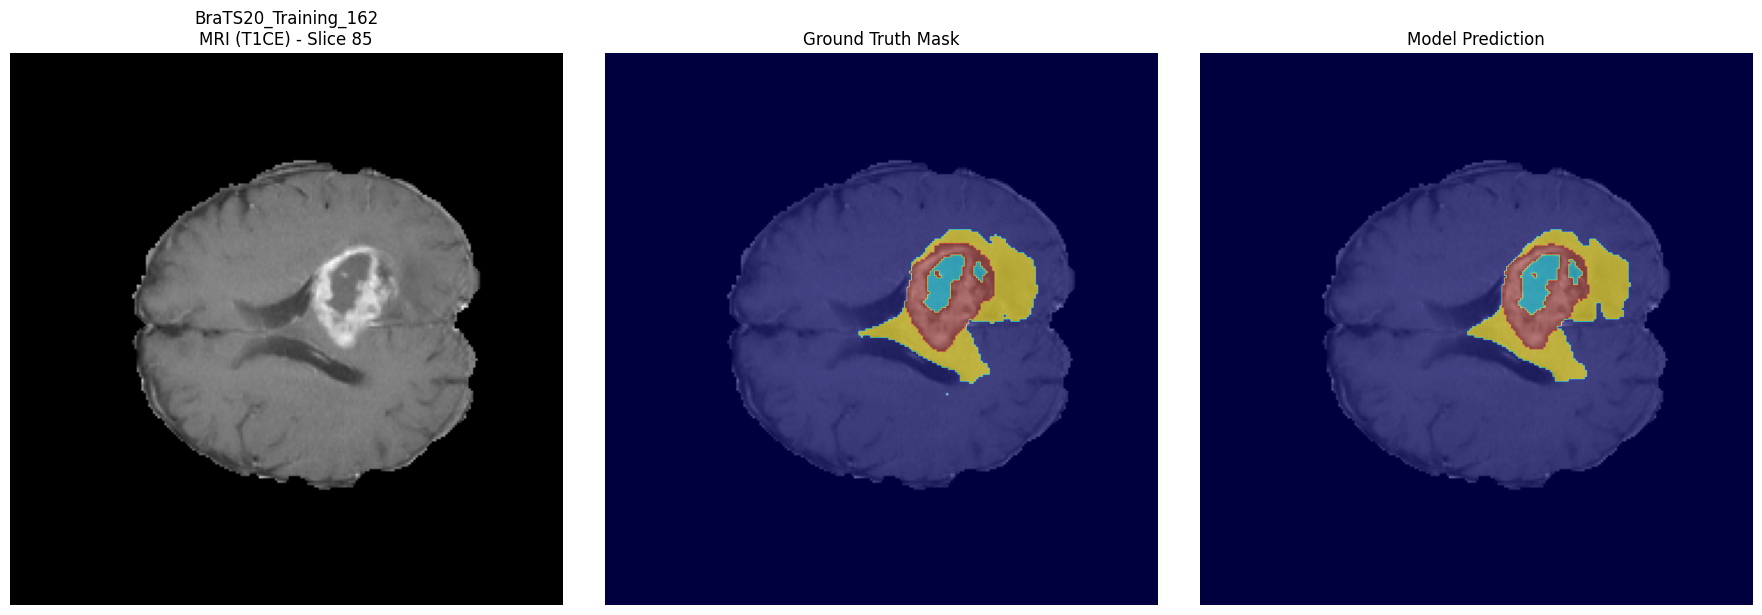

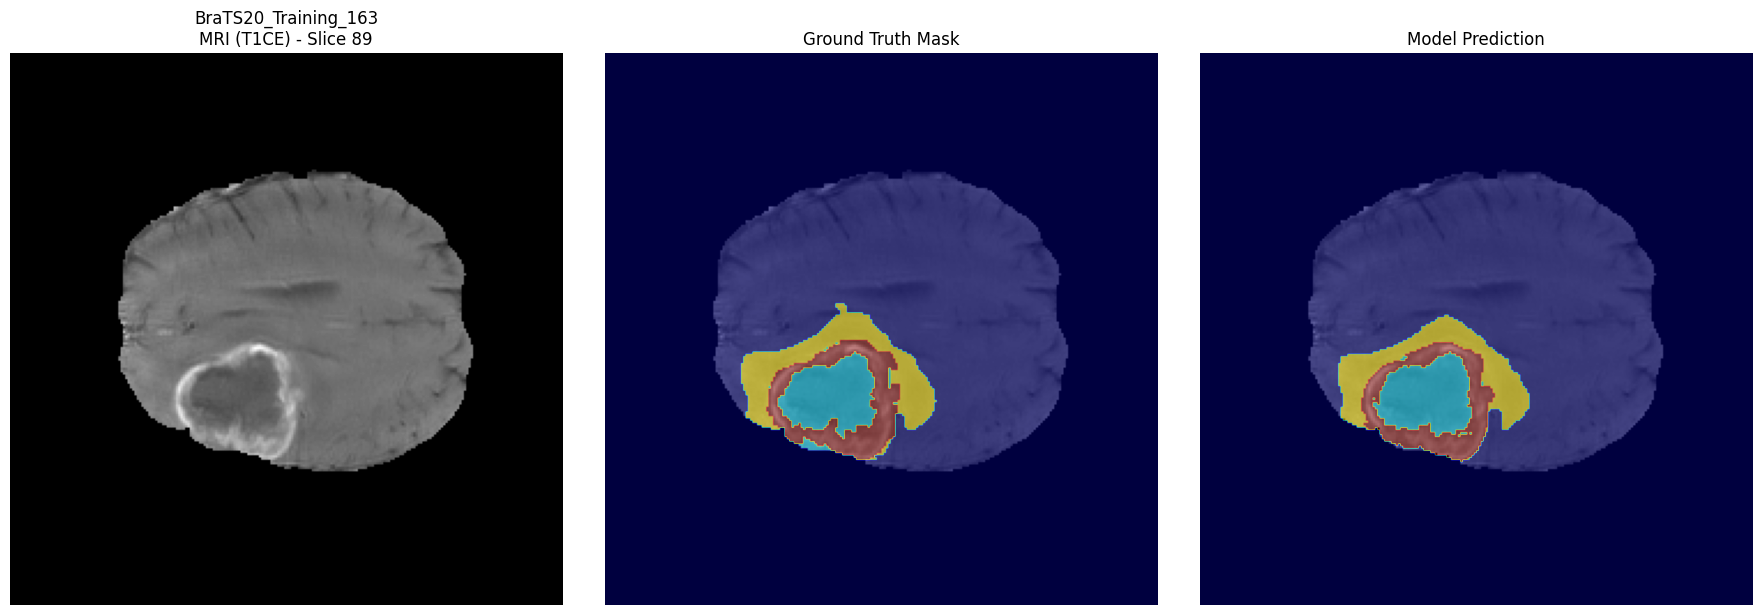

In [ ]:
%matplotlib inline

# select samples from the validation set (val_keys)
if 'val_keys' not in locals():
    import json
    split_path = "/kaggle/working/nnUNet_preprocessed/Dataset001_BraTS2020/splits_final.json"
    with open(split_path, 'r') as f:
        val_keys = json.load(f)[0]['val']

# visualize the first 3 validation cases
samples_to_view = val_keys[:3]

print(f"Visualizing cases: {samples_to_view}")

for case_id in samples_to_view:

    mri_path = imagesTr / f"{case_id}_0002.nii"
    gt_path = labelsTr / f"{case_id}.nii"
    pred_path = output_folder / f"{case_id}.nii"

    # load Data
    mri_data = nib.load(mri_path).get_fdata()
    gt_data = nib.load(gt_path).get_fdata()
    pred_data = nib.load(pred_path).get_fdata()

    # find the slice with the largest tumor area
    tumor_counts = np.sum(gt_data > 0, axis=(0, 1))
    mid_slice = np.argmax(tumor_counts) # Pick slice with most tumor

    # plotting
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # MRI (T1CE)
    axes[0].imshow(mri_data[:, :, mid_slice], cmap='gray')
    axes[0].set_title(f"{case_id}\nMRI (T1CE) - Slice {mid_slice}")
    axes[0].axis('off')

    # Ground Truth Overlay
    axes[1].imshow(mri_data[:, :, mid_slice], cmap='gray')
    axes[1].imshow(gt_data[:, :, mid_slice], cmap='jet', alpha=0.5)
    axes[1].set_title("Ground Truth Mask")
    axes[1].axis('off')

    # Prediction Overlay
    axes[2].imshow(mri_data[:, :, mid_slice], cmap='gray')
    axes[2].imshow(pred_data[:, :, mid_slice], cmap='jet', alpha=0.5)
    axes[2].set_title("Model Prediction")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

## Additional Reference

Standard nnU-Net command to run validation only provides the dice similarity score. 
In order to evaluate the model's performance on other metrics, we have to do the validation process manually without opting for the built-in methods.

In [47]:
!nnUNetv2_train 1 3d_fullres 0 --val --npz


############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2025-12-11 18:13:10.434737: Using splits from existing split file: /kaggle/working/nnUNet_preprocessed/Dataset001_BraTS2020/splits_final.json
2025-12-11 18:13:10.435081: The split file contains 1 splits.
2025-12-11 18:13:10.435191: Desired fold for training: 0
2025-12-11 18:13:10.435322: This sp

Collected scores for 40 validation cases.
Overall Mean Dice: 0.8084


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


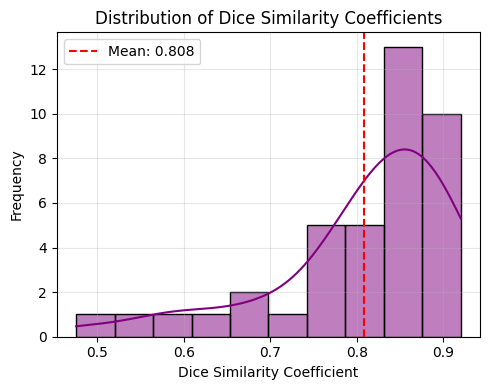

In [ ]:
# val results path
val_output_folder = Path("/kaggle/working/nnUNet_results/Dataset001_BraTS2020/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_0/validation")
summary_file = val_output_folder / "summary.json"

if not summary_file.exists():
    print(f"error: summary file not found at {summary_file}")
else:
    with open(summary_file, 'r') as f:
        summary_data = json.load(f)

    case_dice_scores = []

    for case in summary_data['metric_per_case']:
        dices = [metrics['Dice'] for label, metrics in case['metrics'].items()]

        mean_case_dice = np.mean(dices)
        case_dice_scores.append(mean_case_dice)

    print(f"Collected scores for {len(case_dice_scores)} validation cases.")
    print(f"Overall Mean Dice: {np.mean(case_dice_scores):.4f}")


    plt.figure(figsize=(5, 4))
    sns.histplot(case_dice_scores, kde=True, color='purple', bins=10)

    plt.title('Distribution of Dice Similarity Coefficients')
    plt.xlabel('Dice Similarity Coefficient')
    plt.ylabel('Frequency')


    mean_val = np.mean(case_dice_scores)
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.3f}')

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()